In [13]:
import sys, os
sys.path.append("..")
from datasets import load_dataset
from src.globals import HF_CACHE_DIR
import matplotlib.pyplot as plt


In [12]:
ds = load_dataset("marco-schouten/hidden-objects", split="train", cache_dir=HF_CACHE_DIR)
df = ds.to_pandas()
print(df.shape)
df.head()

(15917203, 8)


,entry_id,bg_path,fg_class,bbox,label,image_reward_score,confidence,source
0,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.542969, 0.591797, 0.0625, 0.152344]",1,-1.542461,0.388181,ho
1,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.542969, 0.587891, 0.0625, 0.158203]",1,-1.598204,0.388575,ho
2,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.574219, 0.671875, 0.082031, 0.255859]",1,-0.420639,0.739268,ho
3,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.574219, 0.568359, 0.083984, 0.253906]",1,-1.412825,0.372770,ho
4,1,data_large_standard/k/kitchen/00002986.jpg,bottle,"[0.554688, 0.806641, 0.128906, 0.191406]",1,-0.831861,0.527968,ho


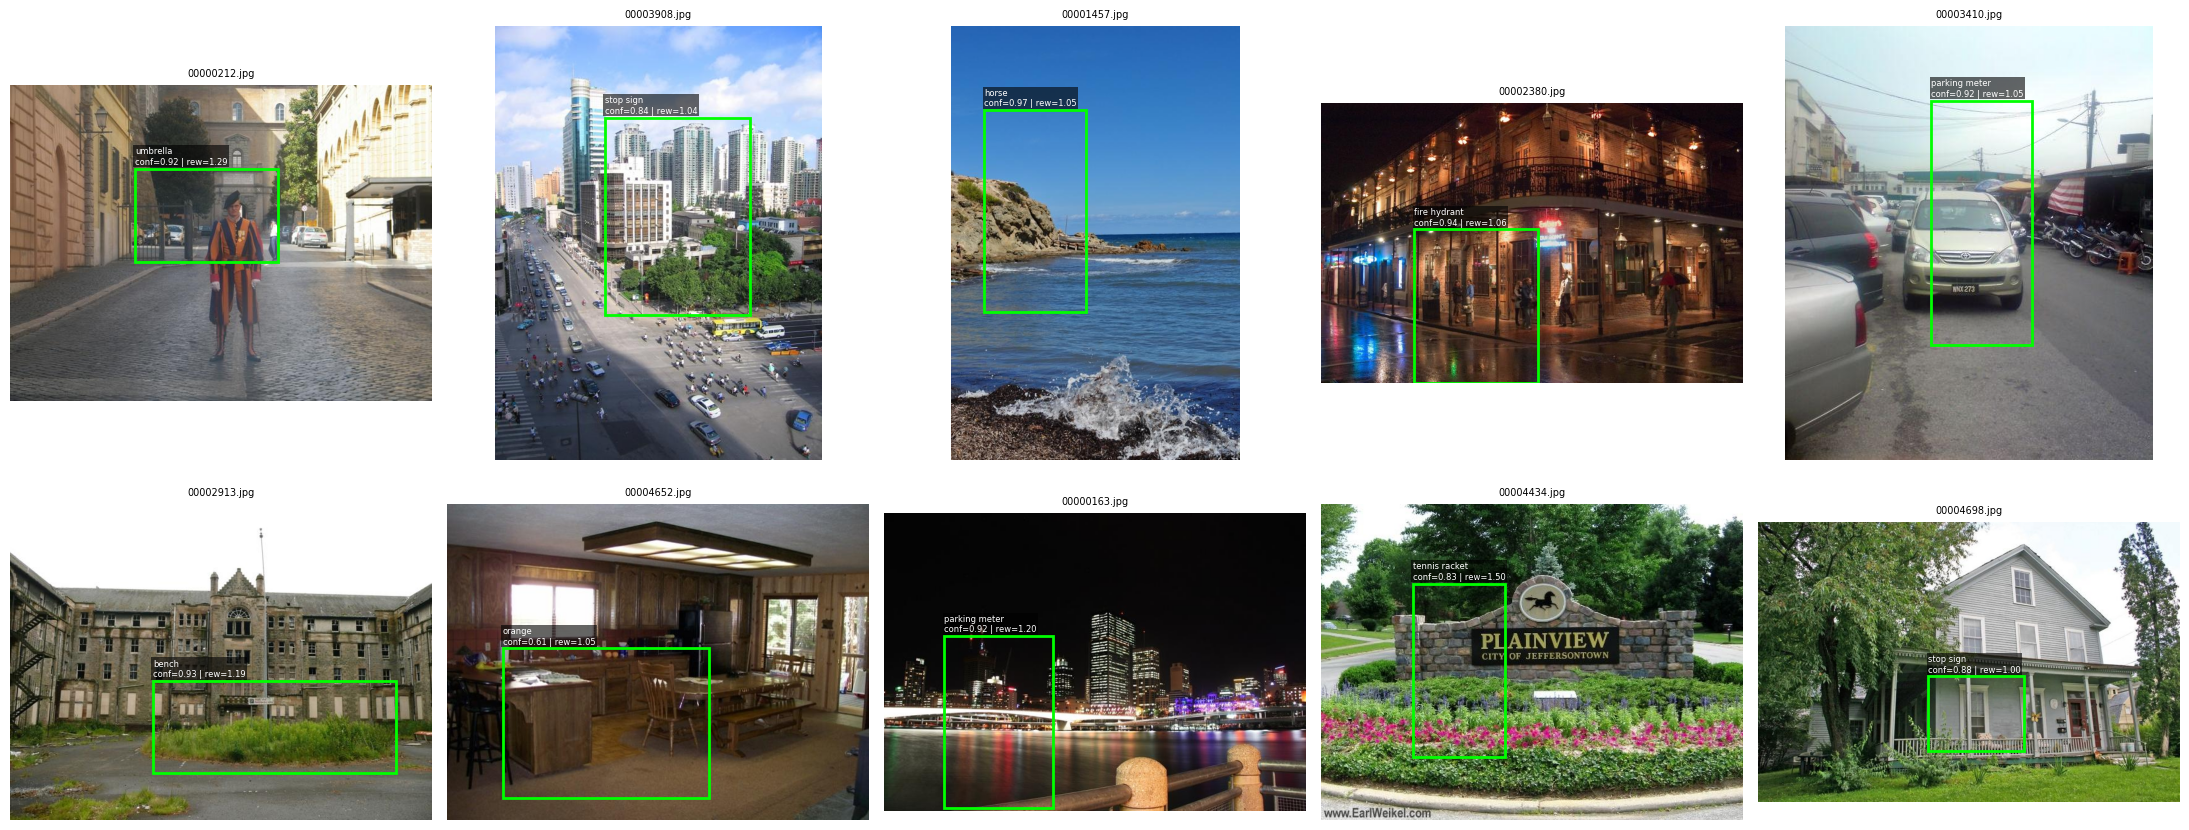

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import sys
sys.path.append("..")

PROJECT_ROOT = Path('..').resolve()
image_root = PROJECT_ROOT / 'data' / 'Places365_trimmed'

# one best bbox per entry_id (highest confidence), then filter high reward + positive
best = df.loc[df.groupby('entry_id')['confidence'].idxmax()]
high_reward = best[(best['image_reward_score'] > 1.0) & (best['label'] == 1)]

unique_imgs = high_reward['bg_path'].unique()
sampled_paths = np.random.choice(unique_imgs, size=min(10, len(unique_imgs)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, bg_path in zip(axes, sampled_paths):
    img = Image.open(image_root / bg_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)

    anns = high_reward[high_reward['bg_path'] == bg_path]
    for _, row in anns.iterrows():
        x, y, w, h = row['bbox']
        rect = patches.Rectangle(
            (x * W, y * H), w * W, h * H,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x * W, y * H - 4,
            f"{row['fg_class']}\nconf={row['confidence']:.2f} | rew={row['image_reward_score']:.2f}",
            color='white', fontsize=6, va='bottom',
            bbox=dict(facecolor='black', alpha=0.6, pad=1, edgecolor='none')
        )

    ax.set_title(bg_path.split('/')[-1], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()
